In [20]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDClassifier
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score

In [21]:
import pandas as pd 
df = pd.read_csv("car_prices.csv")
print(df.head())

  car_id  mileage  selling_price
0   A001   126958           9734
1   A002   151867           8775
2   A003   136932           3928
3   A004   108694          12454
4   A005   124879           6634


In [22]:
df.shape

(300, 3)

In [23]:
df.isnull().sum()

car_id           0
mileage          0
selling_price    0
dtype: int64

In [24]:
X = df[["mileage"]]
y = df["selling_price"]

In [25]:
X_train , X_test ,y_train, y_test = train_test_split(X,y,test_size=0.2 ,random_state=42)

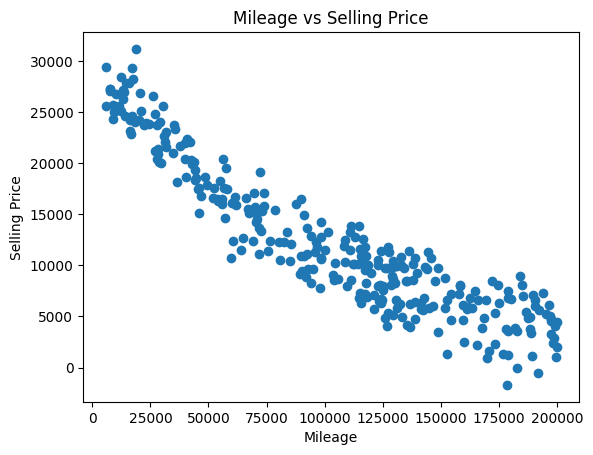

In [27]:
plt.scatter(df["mileage"] ,df["selling_price"])
plt.xlabel("Mileage")
plt.ylabel("Selling Price")
plt.title("Mileage vs Selling Price")
plt.show()

In [28]:
lm = LinearRegression()
lm.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
lm.score(X_test,y_test)

0.8655991728203052

In [30]:
# polynomial regression 
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

In [31]:
lrm = LinearRegression()
lrm.fit(X_train_poly,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
y_poly= lrm.predict(X_test_poly)

In [37]:
r2_score(y_test,y_poly)

0.9157255575176676

In [38]:
y_lin = lm.predict(X_test)

In [39]:
y_poly = lrm.predict(X_test_poly)

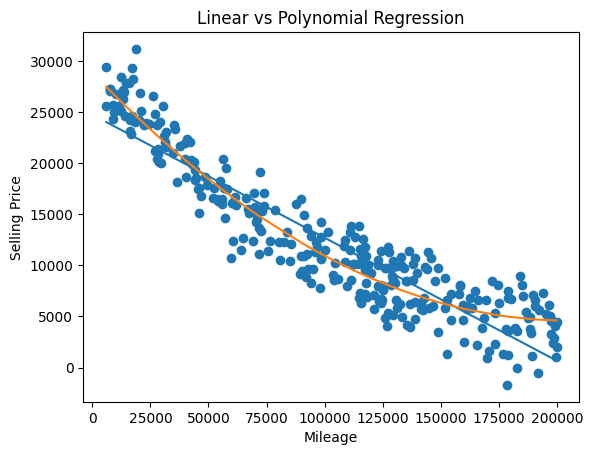

In [43]:
sorted_zip = sorted(zip(X_test.values.flatten(), y_lin, y_poly))
X_sorted, y_lin_sorted, y_poly_sorted = zip(*sorted_zip)

plt.scatter(df["mileage"], df["selling_price"])

plt.plot(X_sorted, y_lin_sorted)
plt.plot(X_sorted, y_poly_sorted)

plt.xlabel("Mileage")
plt.ylabel("Selling Price")
plt.title("Linear vs Polynomial Regression")

plt.show()

In [ ]:
#This is a example of 
#Blue dots = Real data
#Straight line = Linear model
#Curved line = Polynomial model